<a href="https://colab.research.google.com/github/Suhanii054/DEEP-LEARNING/blob/main/LAB-3/DL_Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

import matplotlib.pyplot as plt
import numpy as np
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=64, shuffle=True, num_workers=2)

testloader = torch.utils.data.DataLoader(
    testset, batch_size=64, shuffle=False, num_workers=2)

classes = trainset.classes
print(classes)

100%|██████████| 170M/170M [10:42<00:00, 266kB/s]


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


Labels: ['horse', 'airplane', 'truck', 'dog', 'truck', 'horse', 'frog', 'horse']


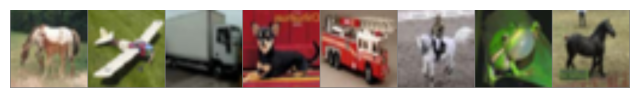

In [ ]:
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.figure(figsize=(8,4))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')

dataiter = iter(trainloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images[:8]))
print("Labels:", [classes[l] for l in labels[:8]])

In [ ]:
def train_model(model, epochs=5, lr=0.001):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(trainloader):.4f}")

    total_time = time.time() - start_time
    return total_time

In [ ]:
def evaluate_model(model):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

In [ ]:
def freeze_backbone(model):
    for param in model.parameters():
        param.requires_grad = False

In [ ]:
def train_model_fast(model, epochs=3, lr=0.001):
    model.to(device)
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss/len(trainloader):.4f}")

    return time.time() - start_time

In [ ]:
vgg16 = models.vgg16(pretrained=True)
freeze_backbone(vgg16)
vgg16.classifier[6] = nn.Linear(4096, 10)

time_vgg = train_model_fast(vgg16, epochs=3)
acc_vgg = evaluate_model(vgg16)

print("VGG16 Accuracy:", acc_vgg)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 90.8MB/s]


Epoch [1/3] Loss: 0.7840
Epoch [2/3] Loss: 0.7210
Epoch [3/3] Loss: 0.7062
VGG16 Accuracy: 80.06


In [ ]:
resnet50 = models.resnet50(pretrained=True)
freeze_backbone(resnet50)
resnet50.fc = nn.Linear(resnet50.fc.in_features, 10)

time_res50 = train_model_fast(resnet50, epochs=3)
acc_res50 = evaluate_model(resnet50)

print("ResNet50 Accuracy:", acc_res50)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 143MB/s]


Epoch [1/3] Loss: 0.7485
Epoch [2/3] Loss: 0.5933
Epoch [3/3] Loss: 0.5690
ResNet50 Accuracy: 80.3


In [ ]:
resnet101 = models.resnet101(pretrained=True)
freeze_backbone(resnet101)
resnet101.fc = nn.Linear(resnet101.fc.in_features, 10)

time_res101 = train_model_fast(resnet101, epochs=3)
acc_res101 = evaluate_model(resnet101)

print("ResNet101 Accuracy:", acc_res101)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth


100%|██████████| 171M/171M [00:00<00:00, 196MB/s]


Epoch [1/3] Loss: 0.6710
Epoch [2/3] Loss: 0.5230
Epoch [3/3] Loss: 0.4959
ResNet101 Accuracy: 83.64


In [ ]:
efficientnet = models.efficientnet_b0(pretrained=True)
freeze_backbone(efficientnet)
efficientnet.classifier[1] = nn.Linear(
    efficientnet.classifier[1].in_features, 10
)

time_eff = train_model_fast(efficientnet, epochs=3)
acc_eff = evaluate_model(efficientnet)

print("EfficientNet Accuracy:", acc_eff)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 232MB/s]


Epoch [1/3] Loss: 0.9076
Epoch [2/3] Loss: 0.7019
Epoch [3/3] Loss: 0.6750
EfficientNet Accuracy: 80.33


In [ ]:
mobilenet = models.mobilenet_v2(pretrained=True)
freeze_backbone(mobilenet)
mobilenet.classifier[1] = nn.Linear(
    mobilenet.classifier[1].in_features, 10
)

time_mob = train_model_fast(mobilenet, epochs=3)
acc_mob = evaluate_model(mobilenet)

print("MobileNet Accuracy:", acc_mob)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 197MB/s]


Epoch [1/3] Loss: 0.8740
Epoch [2/3] Loss: 0.7199
Epoch [3/3] Loss: 0.7085
MobileNet Accuracy: 77.79


In [ ]:
import torchvision.models as tv_models
import torch.nn as nn

inception = tv_models.inception_v3(
    weights=tv_models.Inception_V3_Weights.DEFAULT
)

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 206MB/s] 


In [ ]:
freeze_backbone(inception)

In [ ]:
inception.fc = nn.Linear(inception.fc.in_features, 10)
inception.AuxLogits.fc = nn.Linear(
    inception.AuxLogits.fc.in_features, 10
)

In [ ]:
def train_inception(model, epochs=1, lr=0.001):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs, aux_outputs = model(images)

            loss1 = criterion(outputs, labels)
            loss2 = criterion(aux_outputs, labels)
            loss = loss1 + 0.4 * loss2   # official Inception loss

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss/len(trainloader):.4f}")

In [ ]:
transform_inception = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

In [ ]:
trainset_inc = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=False, transform=transform_inception
)

testset_inc = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=False, transform=transform_inception
)

trainloader_inc = torch.utils.data.DataLoader(
    trainset_inc, batch_size=32, shuffle=True, num_workers=2
)

testloader_inc = torch.utils.data.DataLoader(
    testset_inc, batch_size=32, shuffle=False, num_workers=2
)

In [ ]:
def train_inception(model, epochs=1, lr=0.001):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in trainloader_inc:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs, aux_outputs = model(images)

            loss1 = criterion(outputs, labels)
            loss2 = criterion(aux_outputs, labels)
            loss = loss1 + 0.4 * loss2

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss/len(trainloader_inc):.4f}")

In [ ]:
def evaluate_inception(model):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in testloader_inc:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            if isinstance(outputs, tuple):  # safety
                outputs = outputs[0]

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

In [ ]:
acc_inc = evaluate_inception(inception)
print("InceptionV3 Test Accuracy (No Fine-Tuning):", acc_inc)

InceptionV3 Test Accuracy (No Fine-Tuning): 64.83


In [ ]:
train_inception(inception, epochs=1)
acc_inc = evaluate_inception(inception)

print("InceptionV3 Test Accuracy:", acc_inc)

Epoch [1/1] Loss: 1.2808
InceptionV3 Test Accuracy: 71.33


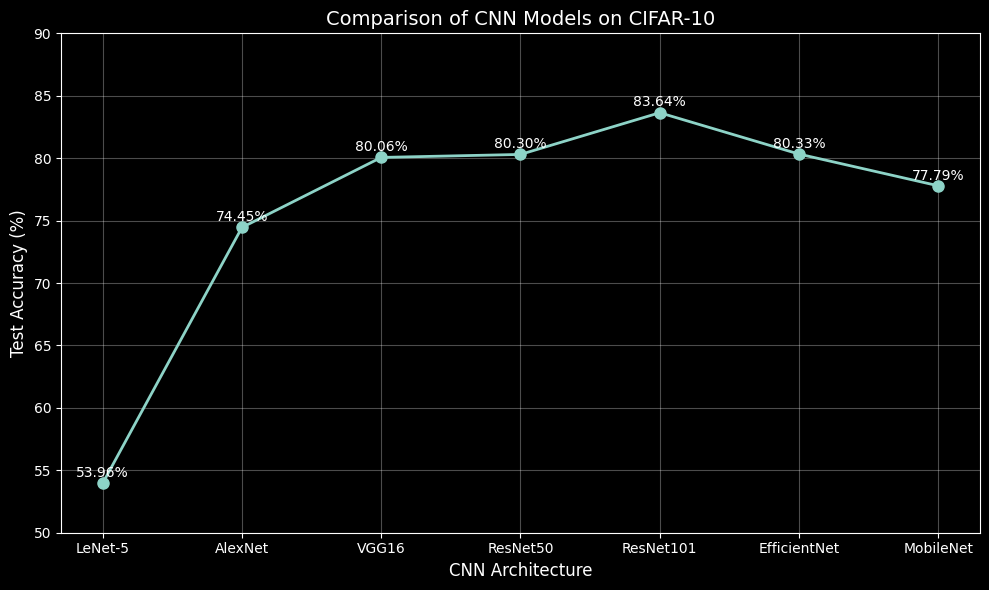

In [ ]:
import matplotlib.pyplot as plt

# Model names and accuracies
models = [
    "LeNet-5",
    "AlexNet",
    "VGG16",
    "ResNet50",
    "ResNet101",
    "EfficientNet",
    "MobileNet"
]

accuracies = [
    53.96,
    74.45,
    80.06,
    80.30,
    83.64,
    80.33,
    77.79
]

# Enable dark theme
plt.style.use("dark_background")

plt.figure(figsize=(10, 6))

# Line plot
plt.plot(
    models,
    accuracies,
    marker='o',
    linewidth=2,
    markersize=8
)

# Annotate exact values near each point
for i, acc in enumerate(accuracies):
    plt.text(
        i,
        acc + 0.5,           # slight offset above the point
        f"{acc:.2f}%",
        ha='center',
        fontsize=10
    )

# Labels and title
plt.xlabel("CNN Architecture", fontsize=12)
plt.ylabel("Test Accuracy (%)", fontsize=12)
plt.title("Comparison of CNN Models on CIFAR-10", fontsize=14)

# Grid (subtle, dark-theme friendly)
plt.grid(alpha=0.3)

plt.ylim(50, 90)

plt.tight_layout()
plt.show()